In [1]:
import h5py
import numpy as np
import nisar_helper_tools
import nisar_download
import pyproj
import matplotlib.pyplot as plt
# Set to your pyproj dir if necessary
pyproj.datadir.set_data_dir('/home/class239/software/miniforge3/envs/eitan/share/proj')

/home/class239/software/miniforge3/envs/eitan/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


### Downloading GSLCs

In [2]:
# Specify file names
files = ["NISAR_L2_PR_GSLC_007_085_D_071_4005_DHDH_A_20251210T023216_20251210T023255_X05009_N_F_J_001"]

In [3]:
# Specify directory and download hdf5 files
# nisar_download.download_files("/raid/class239/erapaport/data/insar/nisar/", files)

### Cropping GSLCs

In [4]:
# These are two subsequent GSLCs of the same track/frame
# Open the HDF5 file in read mode
f11 = h5py.File("/raid/class239/erapaport/data/insar/nisar/NISAR_L2_PR_GSLC_006_085_D_072_4005_DHDH_A_20251128T023250_20251128T023324_X05009_N_F_J_001.h5", 'r')
# Open the HDF5 file in read mode
f12 = h5py.File("/raid/class239/erapaport/data/insar/nisar/NISAR_L2_PR_GSLC_007_085_D_072_4005_DHDH_A_20251210T023250_20251210T023325_X05009_N_F_J_001.h5", 'r')

In [5]:
# These are two subsequent GSLCs of the same track/frame, different frame as above
# Open the HDF5 file in read mode
f21 = h5py.File("/raid/class239/erapaport/data/insar/nisar/NISAR_L2_PR_GSLC_006_085_D_071_4005_DHDH_A_20251128T023216_20251128T023254_X05009_N_F_J_001.h5", 'r')
# Open the HDF5 file in read mode
f22 = h5py.File("/raid/class239/erapaport/data/insar/nisar/NISAR_L2_PR_GSLC_007_085_D_071_4005_DHDH_A_20251210T023216_20251210T023255_X05009_N_F_J_001.h5", 'r')

In [6]:
# Specify bounds to crop
lon_min, lon_max = -115, -116.5
lat_min, lat_max = 33.2, 34

In [7]:
slc11 = f11['science/LSAR/GSLC/grids/frequencyA/HH']
slc12 = f12['science/LSAR/GSLC/grids/frequencyA/HH']
x_coords1 = f11['/science/LSAR/GSLC/grids/frequencyA/xCoordinates'][:]
y_coords1 = f11['/science/LSAR/GSLC/grids/frequencyA/yCoordinates'][:]
direction1 = str(f11['science/LSAR/identification/orbitPassDirection'][()])[2:-1]
epsg_code1 = f11['/science/LSAR/GSLC/grids/frequencyA/projection'].attrs['epsg_code']

In [8]:
slc_subset11, x_coords_subset1, y_coords_subset1 = nisar_helper_tools.crop_slc(slc11, x_coords1, y_coords1, lon_min, lon_max, lat_min, lat_max, epsg_code1, direction1)

In [9]:
slc_subset12, x_coords_subset1, y_coords_subset1 = nisar_helper_tools.crop_slc(slc12, x_coords1, y_coords1, lon_min, lon_max, lat_min, lat_max, epsg_code1, direction1)

In [10]:
slc21 = f21['science/LSAR/GSLC/grids/frequencyA/HH']
slc22 = f22['science/LSAR/GSLC/grids/frequencyA/HH']
x_coords2 = f21['/science/LSAR/GSLC/grids/frequencyA/xCoordinates'][:]
y_coords2 = f21['/science/LSAR/GSLC/grids/frequencyA/yCoordinates'][:]
direction2 = str(f21['science/LSAR/identification/orbitPassDirection'][()])[2:-1]
epsg_code2 = f21['/science/LSAR/GSLC/grids/frequencyA/projection'].attrs['epsg_code']

In [11]:
slc_subset21, x_coords_subset2, y_coords_subset2 = nisar_helper_tools.crop_slc(slc21, x_coords2, y_coords2, lon_min, lon_max, lat_min, lat_max, epsg_code2, direction2)

In [12]:
slc_subset22, x_coords_subset2, y_coords_subset2 = nisar_helper_tools.crop_slc(slc22, x_coords2, y_coords2, lon_min, lon_max, lat_min, lat_max, epsg_code2, direction2)

### Merging SLCS

In [13]:
# Can only merge for SLCs taken in the same track

In [14]:
merged_slc1, x_coords, y_coords = nisar_helper_tools.merge_raster(slc_subset11, slc_subset21, x_coords_subset1, y_coords_subset1, x_coords_subset2, y_coords_subset2)

In [15]:
merged_slc2, x_coords, y_coords = nisar_helper_tools.merge_raster(slc_subset12, slc_subset22, x_coords_subset1, y_coords_subset1, x_coords_subset2, y_coords_subset2)

### Making Multilooked Interferograms

In [16]:
igram, corr, x_coords, y_coords = nisar_helper_tools.calculate_multilooked_interferogram(merged_slc1, merged_slc2, x_coords, y_coords, looks=5, downsample=True, convolution="Gaussian")

### Plotting Wrapped Interferograms

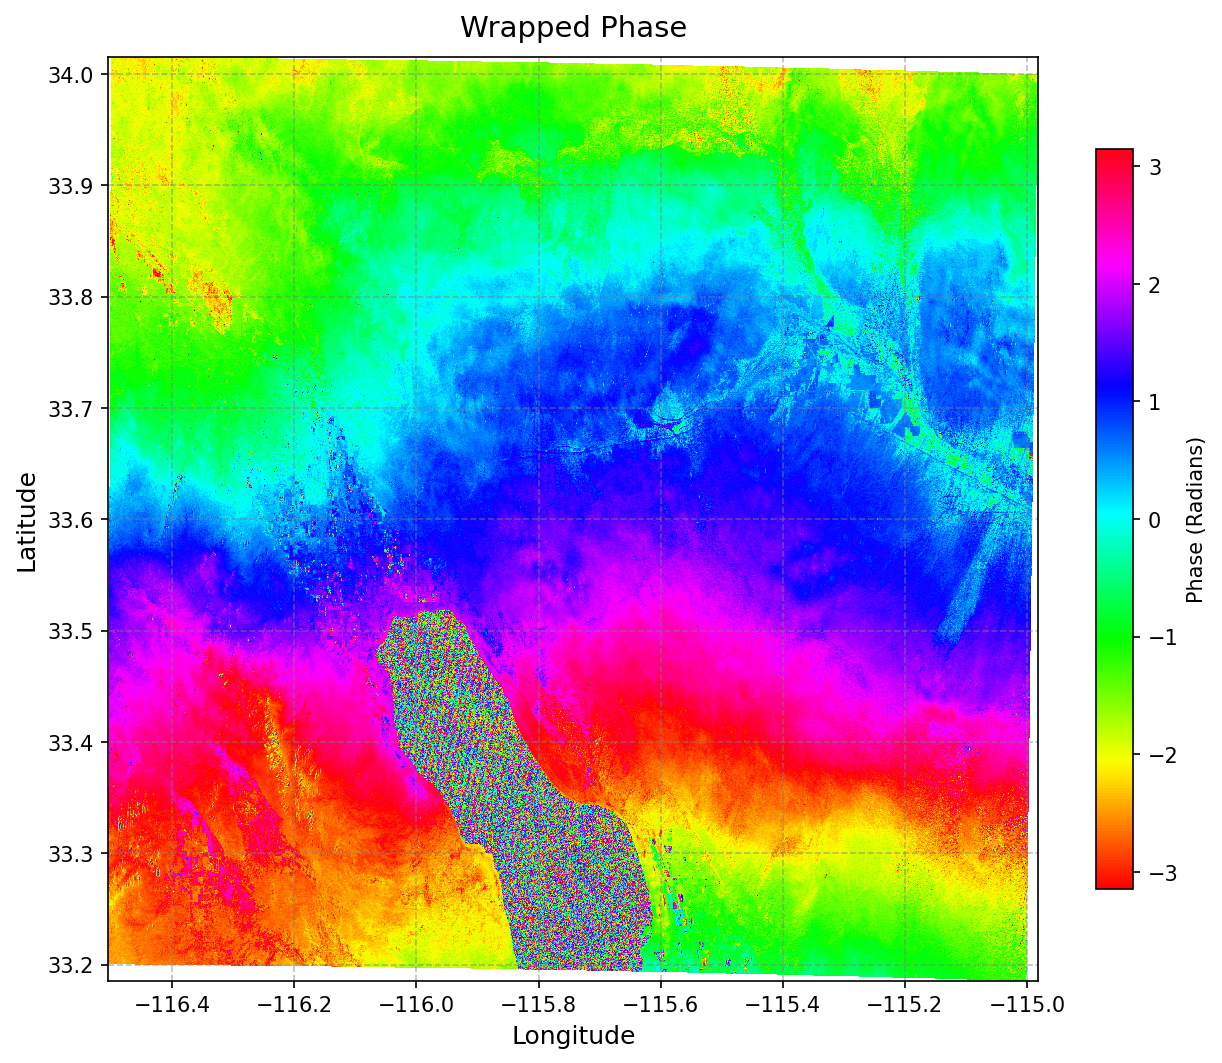

In [17]:
fig, ax = nisar_helper_tools.plot_wrapped_interferogram_phase(igram, x_coords, y_coords, epsg_code1)

### Unwrapping Interferogram

In [18]:
spacing_az=f11['science/LSAR/GSLC/grids/frequencyA/xCoordinateSpacing'][()]
spacing_rg=f11['science/LSAR/GSLC/grids/frequencyA/yCoordinateSpacing'][()]
unw, conncomp = nisar_helper_tools.unwrap_interferogram(igram, corr, nlooks=5, spacing_az=spacing_az, spacing_rg=spacing_rg, res_az=8, res_rg=3, nproc=40)


snaphu v2.0.7
23 parameters input from file /tmp/tmph9prmyks/snaphu.config.kausw1lz.txt (23 lines total)
Starting first-round tile-mode unwrapping
Creating temporary directory /tmp/tmph9prmyks/snaphu_tiles_791393
Unwrapping tile at row 0, column 0 (pid 791394)
Unwrapping tile at row 0, column 1 (pid 791395)
Unwrapping tile at row 0, column 2 (pid 791396)
Unwrapping tile at row 0, column 3 (pid 791397)
Unwrapping tile at row 0, column 4 (pid 791398)
Unwrapping tile at row 0, column 5 (pid 791401)
Unwrapping tile at row 0, column 6 (pid 791403)
Unwrapping tile at row 0, column 7 (pid 791404)
Unwrapping tile at row 1, column 0 (pid 791405)
Unwrapping tile at row 1, column 1 (pid 791406)
Unwrapping tile at row 1, column 2 (pid 791408)
Unwrapping tile at row 1, column 3 (pid 791409)
Unwrapping tile at row 1, column 4 (pid 791410)
Unwrapping tile at row 1, column 5 (pid 791411)
Unwrapping tile at row 1, column 6 (pid 791413)
Unwrapping tile at row 1, column 7 (pid 791414)
Unwrapping tile at

### Plotting Unwrapped Interferogram

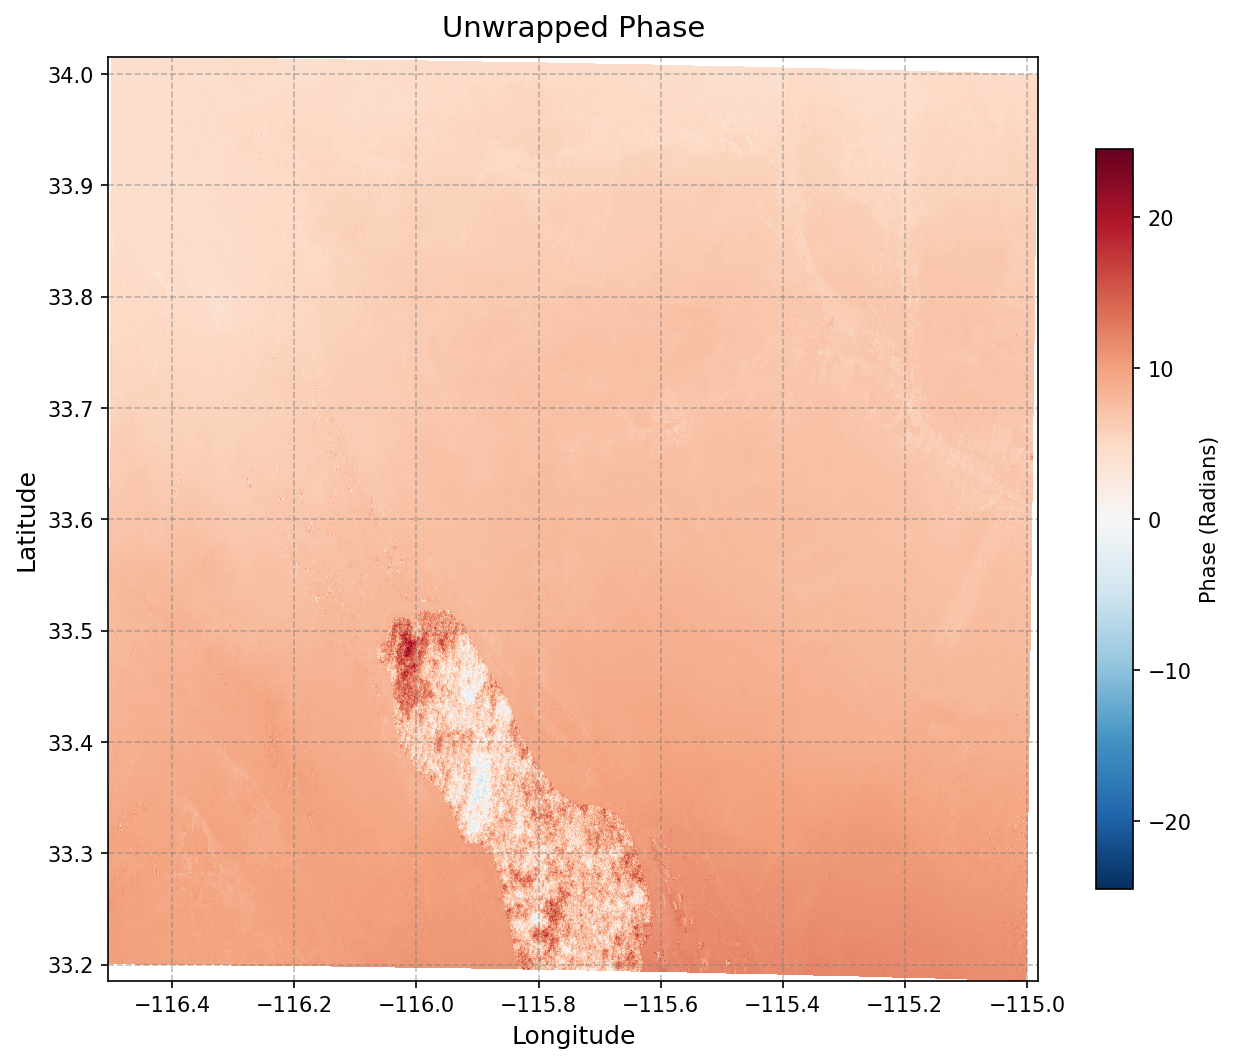

In [19]:
fig, ax = nisar_helper_tools.plot_unwrapped_interferogram_phase(unw, x_coords, y_coords, epsg_code1)

### Masking out water

In [20]:
masked_unw = nisar_helper_tools.mask_water(unw, x_coords, y_coords, epsg_code1)

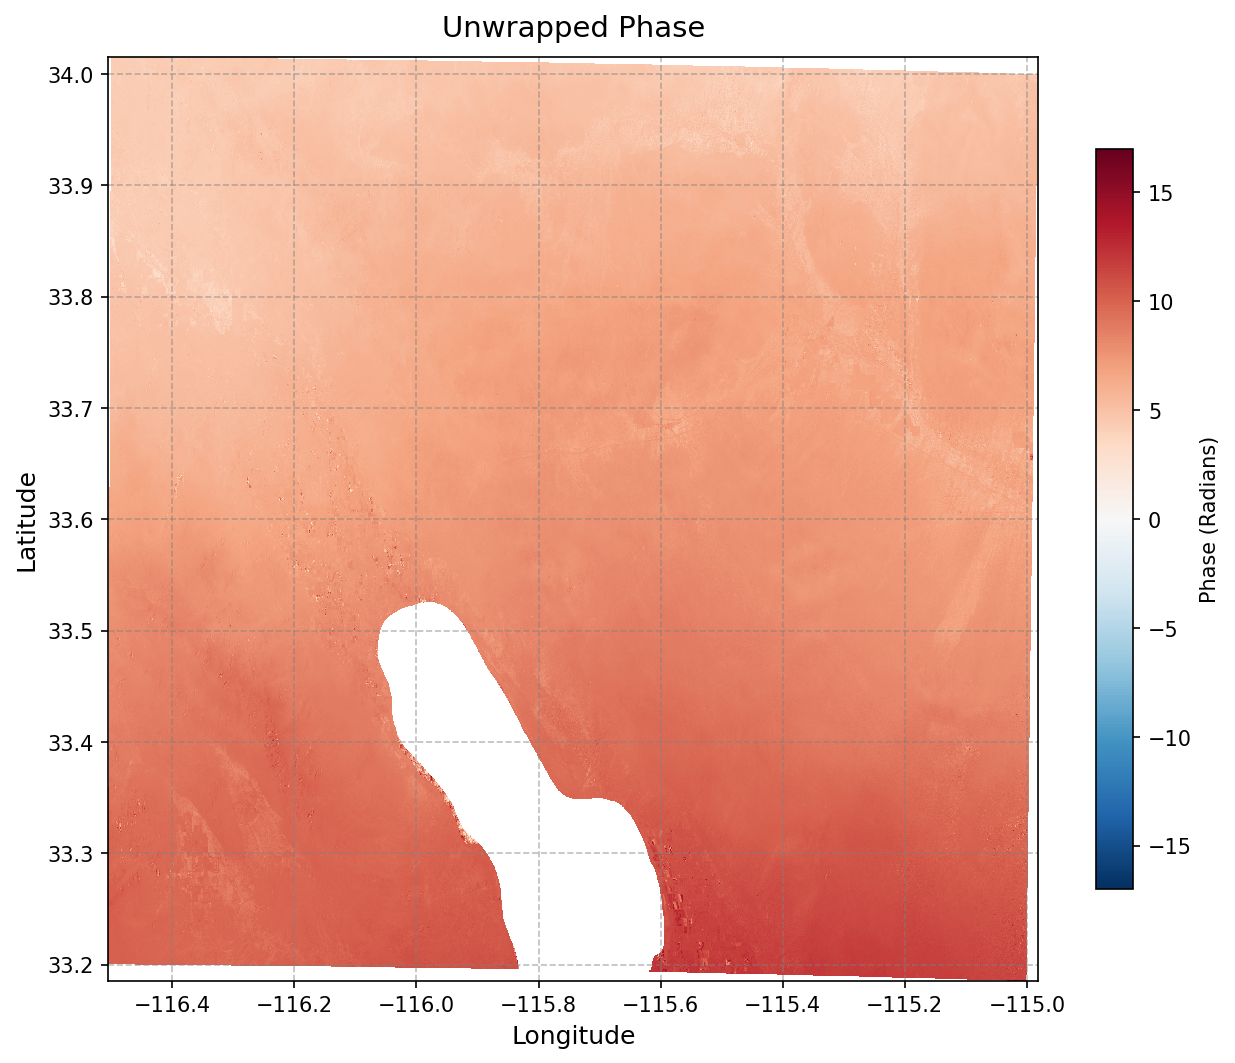

In [21]:
fig, ax = nisar_helper_tools.plot_unwrapped_interferogram_phase(masked_unw, x_coords, y_coords, epsg_code1)

### Save to GRD

In [22]:
unw_interferogram_latlon = nisar_helper_tools.project_to_latlon(masked_unw, x_coords, y_coords, epsg_code1)
# unw_interferogram_latlon.to_netcdf("unwrapped_from_gslc.grd", engine="netcdf4")